In [1]:
from pathlib import Path

import numpy as np
import spikeinterface.full as si
import zarr
from pprint import pprint
from spikeshpc import open_stream, load_states, show_state_epochs, show_state_editor, derive_shutter_times
from spikeshpc import optitrack as optitrack

In [2]:
recording = si.read_openephys(r"C:\Working\session10_pupil\raw",
                              stream_name="OneBox-109.ProbeA",
                              load_sync_timestamps=True
                              )
recording = recording.remove_channels(["CH94", "CH111", "CH141", "CH303", "CH346"])
tv = recording.get_time_info()["time_vector"]

In [15]:
pipeline = si.PreprocessingPipeline({
    'phase_shift': {},
    'center': {'mode': 'mean'},
    'common_reference': {'reference': 'global', 'operator': 'median'}
    }
)
print(pipeline)
scrambled_pipeline = si.PreprocessingPipeline({
    'phase_shift': {},
    'common_reference': {'reference': 'global', 'operator': 'median'},
    'center': {'mode': 'mean'},
    }
)
print(scrambled_pipeline)
rec_shift = si.phase_shift(recording)
rec_bsl = si.center(rec_shift, mode="mean")
rec_cmr = si.common_reference(rec_bsl, reference='global', operator='median')
rec_pipeline = si.apply_preprocessing_pipeline(recording, pipeline)
rec_scrambled = si.apply_preprocessing_pipeline(recording, scrambled_pipeline)
reclist = {
    "manual pipeline": rec_cmr,
    "pipeline output": rec_pipeline,
    "scrambled pipeline output": rec_scrambled,
}

PreprocessingPipeline: 	Raw Recording → phase_shift → center → common_reference → Preprocessed Recording
PreprocessingPipeline: 	Raw Recording → phase_shift → common_reference → center → Preprocessed Recording


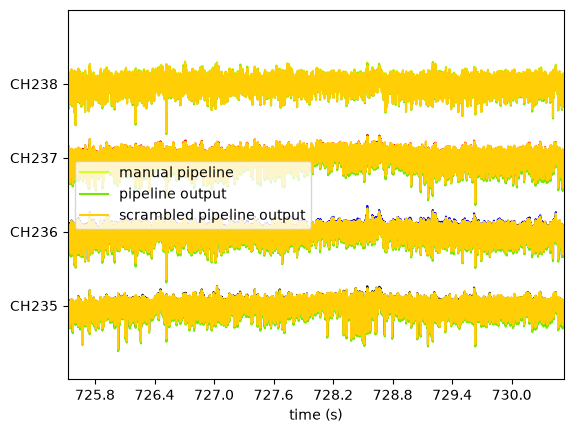

In [19]:
si.plot_traces(recording=reclist,
               time_range=(tv[150000], tv[300000]),
               channel_ids=['CH235', "CH236", "CH237", "CH238"],
               mode='line', return_in_uV=True,
               show_channel_ids=True,
               order_channel_by_depth=True,
               backend='matplotlib')

import matplotlib.pyplot as plt
ax = plt.gca()
ax.lines[0].set_color('black')
ax.lines[1].set_color('blue')
ax.lines[2].set_color('red')
ax.legend()

In [20]:
from kilosort import DEFAULT_SETTINGS

In [26]:
from kilosort import run_kilosort

In [29]:
help(run_kilosort)

Help on function run_kilosort in module kilosort.run_kilosort:

run_kilosort(
    settings,
    probe=None,
    probe_name=None,
    filename=None,
    data_dir=None,
    file_object=None,
    results_dir=None,
    data_dtype=None,
    do_CAR=True,
    invert_sign=False,
    device=None,
    progress_bar=None,
    save_extra_vars=False,
    clear_cache=False,
    save_preprocessed_copy=False,
    bad_channels=None,
    shank_idx=None,
    verbose_console=False,
    verbose_log=False,
    torch_thread_lim=None
)
    Run full spike sorting pipeline on specified data.

    Parameters
    ----------
    settings : dict
        Specifies a number of configurable parameters used throughout the
        spike sorting pipeline. See `kilosort/parameters.py` for a full list of
        available parameters.
        NOTE: `n_chan_bin` must be specified here, but all other settings are
              optional.
    probe : dict; optional.
        A Kilosort4 probe dictionary, as returned by `kilosort.

In [31]:
{n_jobs=16, chunk_duration="1s", progress_bar=True}

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3718896626.py, line 1)